# Project Innowise



In [2]:
import numpy as np
import pandas as pd
from jedi.inference import lazy_value

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

Merge data


In [3]:
items = pd.read_csv('olist_order_items_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
translations = pd.read_csv('product_category_name_translation.csv')
df_raw = (items.merge(orders, on='order_id', how='left')
           .merge(customers, on='customer_id', how='left')
           .merge(products, on='product_id', how='left')
           .merge(translations, on='product_category_name', how='left'))

df = df_raw.sample(n=10000, random_state=24).copy()
display(df.head(30))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
83715,be1aff1e5ed8adabab251a979e96bdb9,3,4052517cac9e78357d895976124f6972,ce27a3cc3c8cc1ea79d11e561e9bebb6,2017-07-21 14:35:13,150.00,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-14 14:35:13,2017-07-17 21:34:59,2017-07-27 16:44:30,2017-08-18 00:00:00,76d5f0e306da4dcc92bb8c4a00b4f891,63260,brejo santo,CE,eletronicos,31.0,736.0,3.0,800.0,35.0,30.0,40.0,electronics
70483,a0e058d95d9625fbb9a4bd69fd6d0996,1,119cfca51257edda1acecb4b8576ec48,cd68562d3f44870c08922d380acae552,2017-08-09 03:10:54,169.00,12.68,1d46f6ccc4985ed63a309848cad48bd5,delivered,2017-08-01 17:18:33,2017-08-03 03:10:54,2017-08-03 18:51:42,2017-08-09 23:07:40,2017-08-21 00:00:00,2bc00078081fa117b125f5bd5e145764,12606,lorena,SP,cool_stuff,59.0,1618.0,3.0,600.0,16.0,14.0,15.0,cool_stuff
28591,411863c544c533d3918d4e274ce334c8,1,e78506414d2563b6414cfd84b7fa0802,fe2032dab1a61af8794248c8196565c9,2017-12-06 12:30:29,152.00,18.34,a8fbdfdfcd4b5f2f67dcd87ca80add6c,delivered,2017-11-29 09:54:11,2017-11-30 13:31:21,2017-12-05 18:13:15,2018-01-03 21:21:59,2017-12-27 00:00:00,16b4e6a5fcbd35d8b50d07c047f30d17,60541,fortaleza,CE,perfumaria,58.0,827.0,1.0,460.0,20.0,14.0,20.0,perfumery
19801,2d736835b63820cfdc9c9e7eef22daf2,1,9bb8ca338e5588c361e34eae02e8fad6,620c87c171fb2a6dd6e8bb4dec959fc6,2017-11-21 02:55:51,59.90,14.01,c06dfa7240c4304b19b4246f3b107d38,delivered,2017-11-14 10:40:21,2017-11-15 02:56:21,2017-11-16 15:34:49,2017-11-17 20:11:36,2017-12-04 00:00:00,4249a1724d282a6356179a862fe02722,27253,volta redonda,RJ,beleza_saude,37.0,314.0,1.0,431.0,19.0,17.0,15.0,health_beauty
71453,a2f4de10fceff6c008efd19d2b99725f,1,cd7f7f00061ea28ae06afc6dc5786cf0,5a8e7d5003a1f221f9e1d6e411de7c23,2018-08-14 12:04:28,79.90,8.72,b66217448555073a1804c56d701fa4e1,delivered,2018-08-11 11:48:41,2018-08-11 12:04:28,2018-08-13 15:09:00,2018-08-15 17:48:37,2018-08-20 00:00:00,74635e4c481883885fbc9429b880df02,13015,campinas,SP,moveis_decoracao,33.0,1183.0,5.0,350.0,68.0,8.0,13.0,furniture_decor
45577,677c865b89aa97e7dbeb4bfbb50bbcfd,1,e2bab04d6a471ed7a3629fbe2a64b55a,beadbee30901a7f61d031b6b686095ad,2018-08-30 23:24:13,85.00,7.86,529d3f46584a8fa9027777a9c7d5a1fc,delivered,2018-08-14 23:08:33,2018-08-14 23:24:13,2018-08-23 12:51:00,2018-08-24 23:42:42,2018-08-31 00:00:00,e1881c7d99c20ca24a49cf18f115db40,2435,sao paulo,SP,perfumaria,51.0,950.0,1.0,300.0,16.0,19.0,14.0,perfumery
64106,92719473371fb9439b386d53d12470a8,1,dc52f0f5d3ec37a93eaf956cde4e5d2c,6560211a19b47992c3666cc44a7e94c0,2017-10-19 20:46:38,49.00,21.15,5944fcd0423637dc7497ef10187e073b,delivered,2017-10-13 19:25:59,2017-10-13 19:46:38,2017-10-16 20:12:41,2017-11-23 21:13:07,2017-11-06 00:00:00,c601f5196438b2836f6de978734b2829,49027,aracaju,SE,relogios_presentes,60.0,539.0,7.0,400.0,16.0,2.0,20.0,watches_gifts
14021,1fedda1b294263f50d8f0f78bf5c3e6a,1,7c2d0df8e5fbfa71d54a400b33a8502e,7e1fb0a3ebfb01ffb3a7dae98bf3238d,2017-05-10 21:25:17,116.00,16.51,08f68c9d6b891c565a87205b547d21a8,delivered,2017-05-04 21:15:50,2017-05-04 21:25:17,2017-05-05 16:26:50,2017-05-16 10:12:49,2017-05-31 00:00:00,fcbbe2856825553e6ed2bfbb252587fc,29730,baixo guandu,ES,beleza_saude,59.0,1515.0,1.0,138.0,12.0,9.0,18.0,health_beauty
44758,65c28faddc1bdb2d3d5de4f713de3f9a,1,a56fbff66c12c1ef311cac69e7f2d5fb,1025f0e2d44d7041d6cf58b6550e0bfa,2018-04-16 04:10:47,45.00,17.06,e8334d453a2049e7a529d772be66ad61,delivered,2018-04-06 12:54:10,2018-04-10 04:10:47,2018-04-11 20:22:01,2018-04-24 18:29:49,2018-05-04 00:00:00,c68a95b096e94c5c6e1f47c06d847171,41770,salv

Adding finantial data

In [4]:
to_delete = ['product_category_name','product_name_lenght','product_description_lenght','product_photos_qty','customer_zip_code_prefix','product_photos_qty','order_approved_at','order_delivered_carrier_date','shipping_limit_date','order_estimated_delivery_date','product_length_cm','product_width_cm','product_height_cm','seller_id','order_item_id']
df = df.drop(columns=to_delete, errors='ignore')
print(df.columns.tolist())

['order_id', 'product_id', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'customer_unique_id', 'customer_city', 'customer_state', 'product_weight_g', 'product_category_name_english']


In [5]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
np.random.seed(24)
df['cost_multiplier'] = np.random.uniform(0.40, 0.70, size=len(df))
df['product_cost'] = round(df['cost_multiplier'] * df['price'],2)
df['profit_margin'] = df['price'] - df['product_cost']
check = df.groupby('product_category_name_english').size().sort_values(ascending=False)
print(len(check))

68


Mapping departments for categories

In [6]:
department_groups = {
    'Home & Living': ['bed_bath_table', 'furniture_decor', 'housewares', 'garden_tools',
                      'home_construction', 'office_furniture', 'home_confort',
                      'furniture_living_room', 'home_appliances', 'home_appliances_2'],

    'Health & Beauty': ['health_beauty', 'perfumery', 'baby', 'diapers_and_hygiene'],

    'Tech & Electronics': ['computers_accessories', 'telephony', 'electronics', 'audio',
                           'computers', 'fixed_telephony', 'tablets_printing_image'],

    'Fashion & Accessories': ['watches_gifts', 'fashion_bags_accessories', 'fashion_shoes',
                              'fashion_male_clothing', 'fashion_female_clothing',
                              'fashion_underwear_beach', 'luggage_accessories'],

    'Sports & Leisure': ['sports_leisure', 'toys', 'consoles_games', 'musical_instruments'],

    'Auto & Tools': ['auto', 'construction_tools_construction', 'costruction_tools_tools',
                     'industry_commerce_and_business'],

    'Books & Media': ['stationery', 'books_general_interest', 'books_technical',
                      'books_imported', 'cds_dvds_musicals', 'dvds_blu_ray'],

    'Food & Drinks': ['food', 'drinks', 'food_drink']
}

full_maping = {}
for dept, categories in department_groups.items():
    for category in categories:
        full_maping[category] = dept
df['Department'] = df['product_category_name_english'].map(full_maping).fillna('Other')
display(df.groupby('Department').size().sort_values(ascending=False))

Department
Home & Living            2971
Tech & Electronics       1481
Health & Beauty          1464
Sports & Leisure         1264
Other                    1022
Fashion & Accessories     843
Auto & Tools              482
Books & Media             352
Food & Drinks             121
dtype: int64

Loyalty program


In [7]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['Loyalty_Status'] = 'Standard'
scd_date = pd.to_datetime('2018-01-01')
unique_cust = df['customer_unique_id'].dropna().unique()
prem_cust = np.random.choice(unique_cust, size=int(len(unique_cust)*0.2), replace=False)
df.loc[(df['customer_unique_id'].isin(prem_cust)) & (df['order_purchase_timestamp'] >= scd_date), 'Loyalty_Status'] = 'Premium'
display(df.head(15))

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,Department,Loyalty_Status
83715,be1aff1e5ed8adabab251a979e96bdb9,4052517cac9e78357d895976124f6972,150.00,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-27 16:44:30,76d5f0e306da4dcc92bb8c4a00b4f891,brejo santo,CE,800.0,electronics,0.688005,103.20,46.80,Tech & Electronics,Standard
70483,a0e058d95d9625fbb9a4bd69fd6d0996,119cfca51257edda1acecb4b8576ec48,169.00,12.68,1d46f6ccc4985ed63a309848cad48bd5,delivered,2017-08-01 17:18:33,2017-08-09 23:07:40,2bc00078081fa117b125f5bd5e145764,lorena,SP,600.0,cool_stuff,0.609854,103.07,65.93,Other,Standard
28591,411863c544c533d3918d4e274ce334c8,e78506414d2563b6414cfd84b7fa0802,152.00,18.34,a8fbdfdfcd4b5f2f67dcd87ca80add6c,delivered,2017-11-29 09:54:11,2018-01-03 21:21:59,16b4e6a5fcbd35d8b50d07c047f30d17,fortaleza,CE,460.0,perfumery,0.699960,106.39,45.61,Health & Beauty,Standard
19801,2d736835b63820cfdc9c9e7eef22daf2,9bb8ca338e5588c361e34eae02e8fad6,59.90,14.01,c06dfa7240c4304b19b4246f3b107d38,delivered,2017-11-14 10:40:21,2017-11-17 20:11:36,4249a1724d282a6356179a862fe02722,volta redonda,RJ,431.0,health_beauty,0.466020,27.91,31.99,Health & Beauty,Standard
71453,a2f4de10fceff6c008efd19d2b99725f,cd7f7f00061ea28ae06afc6dc5786cf0,79.90,8.72,b66217448555073a1804c56d701fa4e1,delivered,2018-08-11 11:48:41,2018-08-15 17:48:37,74635e4c481883885fbc9429b880df02,campinas,SP,350.0,furniture_decor,0.508317,40.61,39.29,Home & Living,Standard
45577,677c865b89aa97e7dbeb4bfbb50bbcfd,e2bab04d6a471ed7a3629fbe2a64b55a,85.00,7.86,529d3f46584a8fa9027777a9c7d5a1fc,delivered,2018-08-14 23:08:33,2018-08-24 23:42:42,e1881c7d99c20ca24a49cf18f115db40,sao paulo,SP,300.0,perfumery,0.621952,52.87,32.13,Health & Beauty,Standard
64106,92719473371fb9439b386d53d12470a8,dc52f0f5d3ec37a93eaf956cde4e5d2c,49.00,21.15,5944fcd0423637dc7497ef10187e073b,delivered,2017-10-13 19:25:59,2017-11-23 21:13:07,c601f5196438b2836f6de978734b2829,aracaju,SE,400.0,watches_gifts,0.698937,34.25,14.75,Fashion & Accessories,Standard
14021,1fedda1b294263f50d8f0f78bf5c3e6a,7c2d0df8e5fbfa71d54a400b33a8502e,116.00,16.51,08f68c9d6b891c565a87205b547d21a8,delivered,2017-05-04 21:15:50,2017-05-16 10:12:49,fcbbe2856825553e6ed2bfbb252587fc,baixo guandu,ES,138.0,health_beauty,0.494904,57.41,58.59,Health & Beauty,Standard
44758,65c28faddc1bdb2d3d5de4f713de3f9a,a56fbff66c12c1ef311cac69e7f2d5fb,45.00,17.06,e8334d453a2049e7a529d772be66ad61,delivered,2018-04-06 12:54:10,2018-04-24 18:29:49,c68a95b096e94c5c6e1f47c06d847171,salvador,BA,600.0,furniture_decor,0.440963,19.84,25.16,Home & Living,Standard
52163,76b25fe0af9b04dfb3c2055e447d4492,06b3951f1930297079eeae756ce88cf8,45.99,8.29,a6ce61a0375ec7c47769053b811cd750,delivered,2018-04-22 17:34:19,2018-04-25 11:41:47,8820aac0f33eaae7691e5f3ec3a61b07,sao paulo,SP,500.0,garden_tools,0.515194,23.69,22.30,Home & Living,Standard


### STAGE 1

In [8]:
df.columns = df.columns.str.lower().str.replace(' ','_')
print(df.columns)

Index(['order_id', 'product_id', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp',
       'order_delivered_customer_date', 'customer_unique_id', 'customer_city',
       'customer_state', 'product_weight_g', 'product_category_name_english',
       'cost_multiplier', 'product_cost', 'profit_margin', 'department',
       'loyalty_status'],
      dtype='str')


In [9]:
print(df.duplicated().sum())
df = df.drop_duplicates()

0


In [10]:
df = df.query("order_status == 'delivered' and product_weight_g > 0").copy()
print(len(df))


9771


In [11]:
df['value_tier'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])
display(df[['price','value_tier']].head(20))

,price,value_tier
83715,150.00,High
70483,169.00,High
28591,152.00,High
19801,59.90,Medium
71453,79.90,Medium
45577,85.00,Medium
64106,49.00,Low
14021,116.00,High
44758,45.00,Low
52163,45.99,Low


In [12]:
df['purchase_day_of_week'] = df['order_purchase_timestamp'].dt.day_name()
display(df[['order_purchase_timestamp','purchase_day_of_week']].head(20))

,order_purchase_timestamp,purchase_day_of_week
83715,2017-07-14 14:20:03,Friday
70483,2017-08-01 17:18:33,Tuesday
28591,2017-11-29 09:54:11,Wednesday
19801,2017-11-14 10:40:21,Tuesday
71453,2018-08-11 11:48:41,Saturday
45577,2018-08-14 23:08:33,Tuesday
64106,2017-10-13 19:25:59,Friday
14021,2017-05-04 21:15:50,Thursday
44758,2018-04-06 12:54:10,Friday
52163,2018-04-22 17:34:19,Sunday


In [13]:
df['category_keyword'] = df['product_category_name_english'].astype(str).str.split('_').str[0]
display(df[['product_category_name_english','category_keyword']].head(20))

,product_category_name_english,category_keyword
83715,electronics,electronics
70483,cool_stuff,cool
28591,perfumery,perfumery
19801,health_beauty,health
71453,furniture_decor,furniture
45577,perfumery,perfumery
64106,watches_gifts,watches
14021,health_beauty,health
44758,furniture_decor,furniture
52163,garden_tools,garden


In [14]:
print(f"Rozmiar danych po wyczyszczeniu: {df.shape}")
display(df[['price', 'value_tier', 'order_purchase_timestamp', 'purchase_day_of_week', 'product_category_name_english', 'category_keyword']].head())

Rozmiar danych po wyczyszczeniu: (9771, 21)


,price,value_tier,order_purchase_timestamp,purchase_day_of_week,product_category_name_english,category_keyword
83715,150.0,High,2017-07-14 14:20:03,Friday,electronics,electronics
70483,169.0,High,2017-08-01 17:18:33,Tuesday,cool_stuff,cool
28591,152.0,High,2017-11-29 09:54:11,Wednesday,perfumery,perfumery
19801,59.9,Medium,2017-11-14 10:40:21,Tuesday,health_beauty,health
71453,79.9,Medium,2018-08-11 11:48:41,Saturday,furniture_decor,furniture


In [15]:
print(df.info())
display(df.head(1))

<class 'pandas.DataFrame'>
Index: 9771 entries, 83715 to 82392
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       9771 non-null   str           
 1   product_id                     9771 non-null   str           
 2   price                          9771 non-null   float64       
 3   freight_value                  9771 non-null   float64       
 4   customer_id                    9771 non-null   str           
 5   order_status                   9771 non-null   str           
 6   order_purchase_timestamp       9771 non-null   datetime64[us]
 7   order_delivered_customer_date  9771 non-null   datetime64[us]
 8   customer_unique_id             9771 non-null   str           
 9   customer_city                  9771 non-null   str           
 10  customer_state                 9771 non-null   str           
 11  product_weight_g            

,order_id,product_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,customer_unique_id,customer_city,customer_state,product_weight_g,product_category_name_english,cost_multiplier,product_cost,profit_margin,department,loyalty_status,value_tier,purchase_day_of_week,category_keyword
83715,be1aff1e5ed8adabab251a979e96bdb9,4052517cac9e78357d895976124f6972,150.0,27.59,826c677b00d964c53329e5ea1b5bddab,delivered,2017-07-14 14:20:03,2017-07-27 16:44:30,76d5f0e306da4dcc92bb8c4a00b4f891,brejo santo,CE,800.0,electronics,0.688005,103.2,46.8,Tech & Electronics,Standard,High,Friday,electronics


In [16]:
prepo = {
    ' De ': ' de ',
    ' Da ': ' da ',
    ' Do ': ' do ',
    ' Das ': ' das ',
    ' Dos ': ' dos '
}
df['customer_city'] = df['customer_city'].str.title().replace(prepo, regex=True)

display(df.groupby('customer_city').size().sort_values(ascending=False))



customer_city
Sao Paulo                      1516
Rio de Janeiro                  687
Belo Horizonte                  262
Brasilia                        195
Curitiba                        144
Campinas                        141
Porto Alegre                    138
Salvador                        122
Guarulhos                       112
Sao Bernardo do Campo            86
Niteroi                          83
Sao Jose dos Campos              82
Fortaleza                        75
Sorocaba                         71
Santo Andre                      71
Santos                           64
Goiania                          63
Osasco                           61
Jundiai                          58
Recife                           51
Barueri                          47
Ribeirao Preto                   46
Florianopolis                    45
Contagem                         44
Carapicuiba                      40
Vitoria                          40
Mogi das Cruzes                  39
Juiz de Fora  

In [17]:
!pip install sweetviz


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import sweetviz as sv
report = sv.analyze(df)
#report.show_html("Brazilian_Ecomerce_report_final.html")

C:\Users\Administrator\PycharmProjects\JupyterProject\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Feature: price                               |█▎        | [ 14%]   00:00 -> (00:01 left)findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight normal, now using 500.
Feature: freight_value       

In [19]:
kolumny_z_brakami = ['product_category_name_english', 'category_keyword']

for kol in kolumny_z_brakami:
    df[kol] = df[kol].fillna('Unknown')

###### Business Reflection:
1) Orders with canceled or unavailable statuses still had monetary values attached. Failing to filter these out would artificially inflate our financial reporting
2) Several records indicated a product weight of 0g or less
3) Exactly 152 records (2% of the sample) lacked an product category. Imputing these missing values with an Unknown tag allowed us to retain the revenue data without breaking grouping functions
4) City names suffered from case-sensitivity issues (uppercase vs. lowercase Portuguese prepositions like 'de' or 'da'), which would have artificially multiplied the number of unique cities in our aggregations
5) The dataset contained numerous columns that are irrelevant for C-level strategic analysis (e.g. exact package dimensions in cm, or product description length in characters)

Valuable for the Director:

Day of the Week: Reveals recurring sales patterns, enabling the Director to optimize operations—such as warehouse staffing, customer support, and marketing budgets—around peak days.

Category Keyword: Executives require a high-level strategic view rather than analyzing 70 micro-categories. Even though a simple "first word" extraction loses some nuance (e.g., reducing "bed_bath_table" to just "bed"), the clarity and speed of identifying macro trends are far more valuable for strategic decisions than 100% precision.


findfont: Failed to find font weight normal, now using 500.
findfont: Failed to find font weight bold, now using 500.
findfont: Failed to find font weight normal, now using 500.


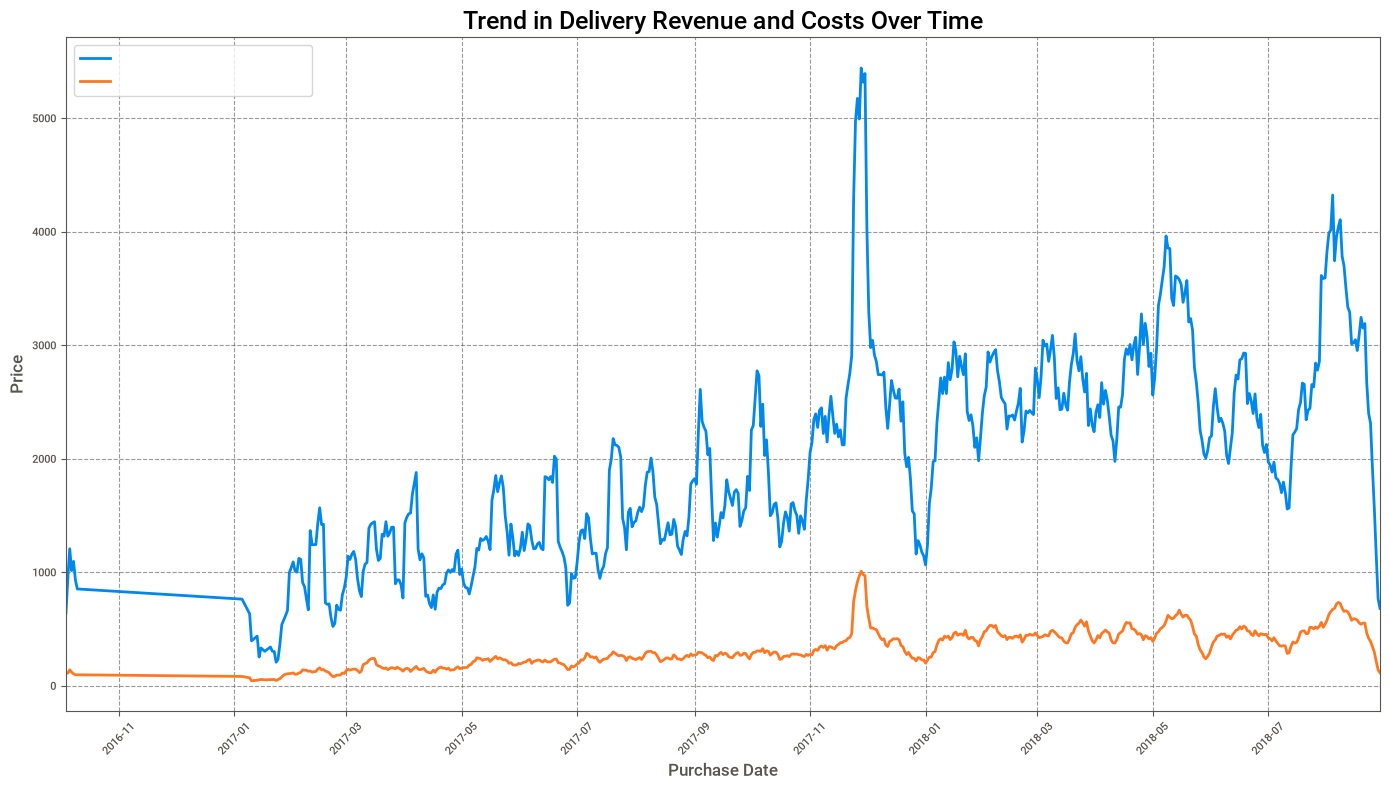

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
df['purchase_date'] = df['order_purchase_timestamp'].dt.date
daily_data = df.groupby('purchase_date')[['price','freight_value']].sum().reset_index()
daily_data['price_7d_avg'] = daily_data['price'].rolling(window=7, min_periods=1).mean()
daily_data['freight_value_7d_avg'] = daily_data['freight_value'].rolling(window=7, min_periods=1).mean()
df_melted = daily_data.melt(
    id_vars='purchase_date',
    value_vars=['price_7d_avg','freight_value_7d_avg'],
    var_name='Metric',
    value_name='Value'
)

df_melted['Metric'] = df_melted['Metric'].replace({
    'price_7d_avg': 'Revenues (7days avg)',
    'freight_value_7d_avg': 'Shipping Costs (7days avg)',
})
#display(df_melted.head(15))
plt.figure(figsize=(14,8))
lplot=sns.lineplot(
    data=df_melted,
    x='purchase_date',
    y='Value',
    hue='Metric',
    linewidth=2,
    legend="brief"
)
first_date = df_melted['purchase_date'].min()
last_date = df_melted['purchase_date'].max()
lplot.set_xlim(first_date, last_date)

plt.title("Trend in Delivery Revenue and Costs Over Time", fontsize=18, fontweight='bold',color='black')
plt.xlabel("Purchase Date", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True,linestyle='--', alpha=0.6)
plt.legend(title=None,loc='upper left',fontsize=11)
plt.tight_layout()
plt.show()
